In [3]:
import pandas as pd
df = pd.read_csv("..\..\data\metadata_(for_scores).csv")

In [7]:
X = df[['melanoma_color_count', 'hue_variance', 'saturation_variance', 'value_variance', 
        'mabrouk_asymmetry_score', 'avg_asymmetry_score', 'worst_score', 
        'Polsby-Popper', 'convexity_score', 'lesion_red_share', 
        'lesion_green_share', 'lesion_blue_share', 'lesion_skin_red_diff', 
        'lesion_skin_green_diff', 'lesion_skin_blue_diff', 'lesion_skin_rgb_distance']]

y = df['skin_cancer_diagnosis']

In [6]:
X= df[['lesion_green_share', 'mabrouk_asymmetry_score', 'saturation_variance',
       'melanoma_color_count', 'convexity_score', 'avg_asymmetry_score',
       'lesion_red_share', 'worst_score', 'lesion_skin_green_diff',
       'lesion_skin_red_diff']]

y = df['skin_cancer_diagnosis']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def get_scores(clf, X, y):
    # try predict_proba, else decision_function
    if hasattr(clf, "predict_proba"):
        probs = clf.predict_proba(X)
        # binary -> take column 1, multiclass -> use full matrix
        if probs.shape[1] == 2:
            return roc_auc_score(y, probs[:, 1])
        else:
            return roc_auc_score(y, probs, multi_class="ovr", average="macro")
    elif hasattr(clf, "decision_function"):
        scores = clf.decision_function(X)
        return roc_auc_score(y, scores)
    else:
        # fallback to predicted labels (not ideal for AUC)
        preds = clf.predict(X)
        return roc_auc_score(y, preds)

# containers
n_est_metrics = {"train": [], "val": []}
print("Evaluating n_estimators:")

n_estimators = [1, 5, 10, 50, 100]
for n in n_estimators:
    rf = RandomForestClassifier(n_estimators=n, max_depth=1, random_state=1907)
    rf.fit(X_train, y_train)

    train_auc = get_scores(rf, X_train, y_train)
    val_auc = get_scores(rf, X_test, y_test)

    n_est_metrics["train"].append(train_auc)
    n_est_metrics["val"].append(val_auc)

    print(f"n_estimators = {n} - Train AUC: {train_auc:.4f} - Val AUC: {val_auc:.4f}")

# Evaluate different max_depth values
max_depth_metrics = {"train": [], "val": []}
print("\nEvaluating max_depth:")

depths = [1, 5, 10, 20, None]
for d in depths:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=1907)
    rf.fit(X_train, y_train)

    train_auc = get_scores(rf, X_train, y_train)
    val_auc = get_scores(rf, X_test, y_test)

    max_depth_metrics["train"].append(train_auc)
    max_depth_metrics["val"].append(val_auc)

    print(f"max_depth = {d} - Train AUC: {train_auc:.4f} - Val AUC: {val_auc:.4f}")


Evaluating n_estimators:
n_estimators = 1 - Train AUC: 0.6240 - Val AUC: 0.5804
n_estimators = 5 - Train AUC: 0.7335 - Val AUC: 0.7204
n_estimators = 10 - Train AUC: 0.7456 - Val AUC: 0.7188
n_estimators = 50 - Train AUC: 0.7822 - Val AUC: 0.7521
n_estimators = 100 - Train AUC: 0.7834 - Val AUC: 0.7494

Evaluating max_depth:
max_depth = 1 - Train AUC: 0.7834 - Val AUC: 0.7494
max_depth = 5 - Train AUC: 0.8788 - Val AUC: 0.7979
max_depth = 10 - Train AUC: 0.9896 - Val AUC: 0.8061
max_depth = 20 - Train AUC: 1.0000 - Val AUC: 0.7969
max_depth = None - Train AUC: 1.0000 - Val AUC: 0.7954


In [20]:


n_est_metrics = {"train":[], "val":[]}

#Evaluate with different number of trees in the ensemble
print(f"Evaluating n_estimators:")

n_estimators = [1,5,10,50,100]
# your code here
for n in n_estimators:
    random_forest = RandomForestClassifier(n_estimators= n,
                                           max_depth= 1,
                                           random_state= 1907,

                                           )
    random_forest.fit(X_train, y_train)
    
    print(f"n_estimators = {n} - Train_acc: {random_forest.score(X_train, y_train)} - val_acc: {random_forest.score(X_test, y_test)}")

#Evaluate with different maximum depth for trees
max_depth_metrics = {"train":[], "val":[]}

print(f"\nEvaluating max_depth:")

depths = [1,5,10,20,None]
for n in depths:
    random_forest = RandomForestClassifier(n_estimators= 100,
                                           max_depth= n,
                                           random_state= 1907,

                                           )
    random_forest.fit(X_train, y_train)
    
    print(f"max_depths = {n} - Train_acc: {random_forest.score(X_train, y_train)} - val_acc: {random_forest.score(X_test, y_test)}")


Evaluating n_estimators:
n_estimators = 1 - Train_acc: 0.5570149253731344 - val_acc: 0.5202863961813843
n_estimators = 5 - Train_acc: 0.68 - val_acc: 0.6945107398568019
n_estimators = 10 - Train_acc: 0.6985074626865672 - val_acc: 0.6467780429594272
n_estimators = 50 - Train_acc: 0.7014925373134329 - val_acc: 0.6945107398568019
n_estimators = 100 - Train_acc: 0.72 - val_acc: 0.6968973747016707

Evaluating max_depth:
max_depths = 1 - Train_acc: 0.72 - val_acc: 0.6968973747016707
max_depths = 5 - Train_acc: 0.8143283582089552 - val_acc: 0.7064439140811456
max_depths = 10 - Train_acc: 0.96 - val_acc: 0.7255369928400954
max_depths = 20 - Train_acc: 1.0 - val_acc: 0.7231503579952268
max_depths = None - Train_acc: 1.0 - val_acc: 0.7303102625298329


In [10]:
random_forest = RandomForestClassifier(n_estimators= 50,
                                           max_depth= 10,
                                           random_state= 42,
                                        class_weight='balanced',
                                        
                                           )
random_forest.fit(X_train, y_train)

print(f"Train_acc: {random_forest.score(X_train, y_train)} - val_acc: {random_forest.score(X_test, y_test)}")

Train_acc: 0.946865671641791 - val_acc: 0.7303102625298329


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

# cross-validated ROC AUC
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"ROC AUC mean: {scores.mean():.4f}  std: {scores.std():.4f}")


ROC AUC mean: 0.8103  std: 0.0277


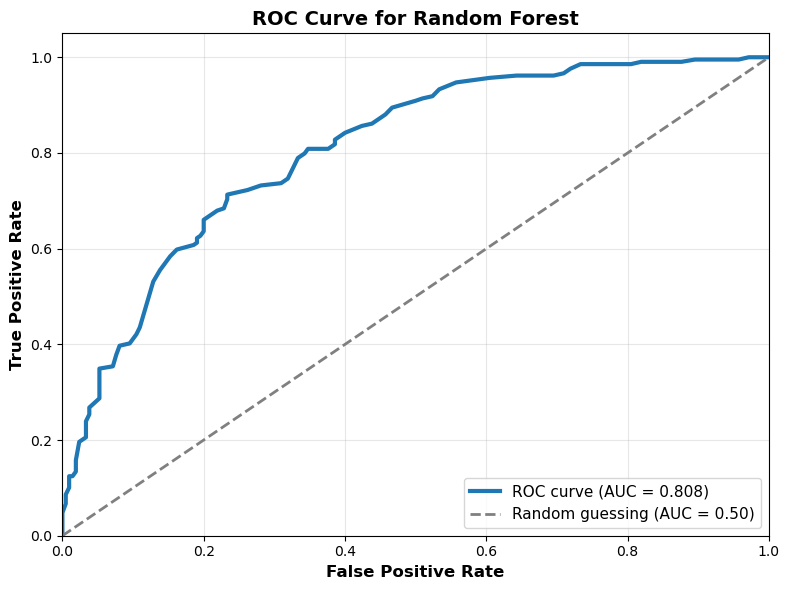

ROC AUC = 0.8076


In [34]:
# Plot ROC curve for the Random Forest model
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', linewidth=3, label=f'ROC curve (AUC = {roc_auc_value:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Random guessing (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve for Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f'ROC AUC = {roc_auc_value:.4f}')

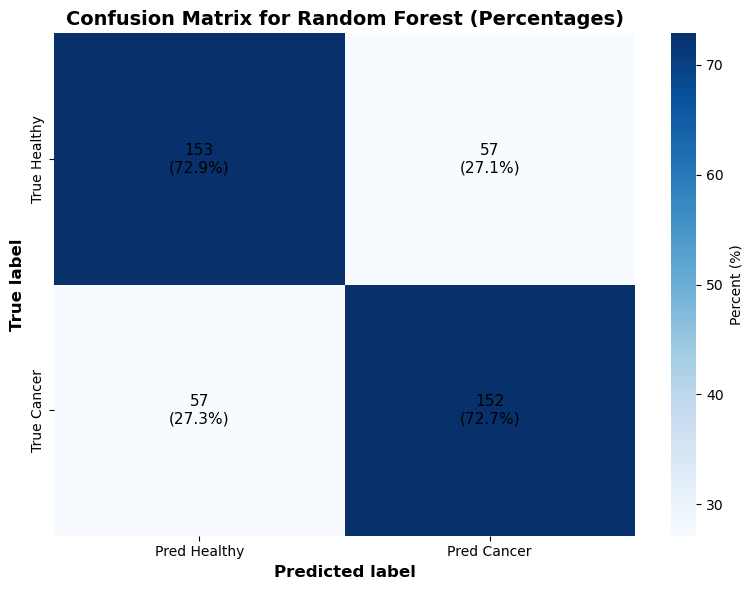

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predicted labels for the test set (use the fitted model)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

labels = ['Healthy', 'Cancer']

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pct, annot=False, cmap='Blues', cbar=True,
            xticklabels=[f'Pred {l}' for l in labels],
            yticklabels=[f'True {l}' for l in labels],
            cbar_kws={'label': 'Percent (%)'})

# Add count + percentage annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j + 0.5, i + 0.5,
                 f'{cm[i, j]}\n({cm_pct[i, j]:.1f}%)',
                 ha='center', va='center', color='black', fontsize=11)

plt.xlabel('Predicted label', fontsize=12, fontweight='bold')
plt.ylabel('True label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix for Random Forest (Percentages)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
estimators = [10, 50, 100, 200, 300, 500]

mean_auc = {n: [] for n in estimators}
std_auc = {n: [] for n in estimators}

for n in estimators:
    for depth in depths:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )
        scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
        mean_auc[n].append(scores.mean())
        std_auc[n].append(scores.std())

x_positions = list(range(len(depths)))
labels = [str(d) for d in depths]

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, n in enumerate(estimators):
    ax.errorbar(
        x_positions,
        mean_auc[n],
        yerr=std_auc[n],
        fmt='-o',
        capsize=3,
        linewidth=2.2,
        markersize=6,
        color=colors[i],
        label=f'n_estimators={n}'
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(labels)
ax.set_xlabel('Tree Depth', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean AUROC (5-fold CV)', fontsize=12, fontweight='bold')
ax.set_title('Random Forest: AUROC by Depth and Number of Estimators', fontsize=15, fontweight='bold')
ax.legend(title='Estimators', fontsize=10, title_fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.55, 1])

plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

50 estimators
depth på 10
næsten ingen benefit ved at gøre den større